Computational Models for Sustainable Chemical Systems
==============


In this lecture block we will study how computational models support the development of sustainable chemical systems with a particular focus on data-driven models.  Together we will:

* dive into the foundations of modelling
* develop data-driven models with hands-on examples (toxicity and solubility predictions)
* apply the models for selecting solvents in line with green chemistry principles

# General information

##  Lecturer
**Dr.-Ing. Laura König-Mattern**
**Group Leader for Computational Biorefining**  
Center for the Transformation of Chemistry  
Mail: laura.koenig-mattern@ctc-germany.org  
Homepage: [https://transforming-chemistry.org/forschung/forschungsgruppen/#biorefineries](https://transforming-chemistry.org/forschung/forschungsgruppen/#biorefineries)

<center> <img src="../img/CTC_logo.png" alt="../img/CTC_logo.png"  width="200"/> </center>

* background in **Process Engineering** 
    * Bachelor in **Biosystems Engineering** (Otto von Guericke University Magdeburg)
    * Master in **Systems Engineering and Engineering Cybernetics** (Otto von Guericke University Magdeburg)
* PhD and research on **computer-aided molecular and process design for biorefineries** at Max Planck Institute for Dynamics of Complex Technical Systems
* Guest PhD at EPFL in Lausanne in the the **Sustainable and Catalytic Processing** Lab

## Course materials
You can find all course materials on GitHub: [Sustainable Chemical Systems Course](https://github.com/koenigmattern/sustainable_chemical_systems_course)
* Our lectures are a mix of theory and hands-on coding (Python). Therefore, the course contents are implented in a jupyter notebook that you can run locally on your machine or simply open it in Google colab (Installation instructions see below)
* PDFs: If you rather prefer pdfs, check out the "script"-folder. At the end of the lecture, I will provide you with a complete script of our lecture block.

## Installation
Find all installation instructions [here](../suschemsys/Installation.ipynb)

## Literature

**Books:**
* `Process Systems Analysis and Control by D.R. Coughanowr and McGraw-Hill`: A classic for modelling process systems and process control.
* `Deep Learning by I. Goodfellow, Y. Bengio and A. Courville`: Open access, authored by pioneers on deep learning.
* `Hands-On Machine Learning with Scikit-Learn and TensorFlow by A. Geron`: For people who prefer learning by doing.

**Online Courses:**
* `Deep Learning Specialization by Andrew Ng, K. Katanforoosh and B. Mourri` from Coursera learning platform: A course series that requires a minumum of mathematical skills but still brings you from zero to a very good understanding and practical training on deep learning.
* `Machine Learning for Chemical Engineering by E. A. del Rio Chanona`: New course from the OptiML PSE Lab @ Imperial College London, highly recommended to take a look at the first lectures and stay tuned for more!

## Note
The code we develop is optimized for educational purposes rather than for performance. I tried to keep it as simple and yet informative as possible to make it accessible to various level of coding experience.

### Colab compatibility

To make the notebook compatible with Google colab, we need to make some adjustments to the paths. The code snippet detects whether we run the notebook in colab or on our local machine. Then, we define the paths depending on this:

In [23]:
from pathlib import Path

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    # either clone repo or use Drive path
    PROJECT_ROOT = Path('/content/sustainable_chemical_systems_course')  # if cloning
else:
    PROJECT_ROOT = Path.cwd().parent


def conv_name(path):
    new_path = str(PROJECT_ROOT / path)
    return new_path

# Course outline

Our lectures will evolve around the following practical example: **Identifying "green" solvents for lignin dissolution**

Lignin dissolution is an important step in **extracting lignin from biomass** but also for **lignin processing** into bio-based materials such as lignin-based coatings, films and nanoparticles. Therefore, solvents are commonly involved in may process units starting from extraction, followed by separation, up to the final product.

Utilizing lignin is sometimes directly dubbed as "green". However, the solvent choice is a design decision that is made on the molecular level with far reaching implications for its impact on environment, safety, and energy demand on the overall process system. Still today, solvent selection is often guided by intution and experience. Computational models can accelerate the search and contribute to a rational solvent choice based on a systematic decision process.

In this course block, we will:
* develop a data-driven model in Python for predicting acute toxicity for chemicals
* explore graph neural networks for predicting lignin solubility
* learn computational approaches for solvent selection in line with the principles of green chemistry
* perform a solvent screening to identify solvents in line with green chemistry principles

On the fly, we will dive into the fundamentals of modelling, machine learning and learn a lot about toxicity and lignin dissolution as well!

# Problem formulation

## The inverse problem
**Direct problem**: Given a defined molecular structure, predict one ore more target property.
**Inverse problem**: Given one or more target properties, identify the molecular structure.

Our problem: We want to identify a solvent that:
* dissolves lignin well (maximizes lignin solubility)
* is in line the principles of green chemistry (due to the limited time we have in our course, we will focus on acute toxicity only)

The search for the optimal solvent is therefore categorized as an **inverse problem**: 



<center> <img src="../img/inverse_problem.jpg" alt="../img/inverse_problem.jpg" width="300"/> </center>
*<sub> from [Current Opinion in Chemical Engineering](https://www.sciencedirect.com/science/article/pii/S2211339819300619), `Gertig et al., Computer-aided molecular and processes design based on quantum chemistry: current status and future prospects, Current Opinion in Chemical Engineering, 2020.` </sub>*


However, finding the optimal structure in the vast **chemical space** is a complex problem. The chemical space comprises all possible stable chemical compounds, defined by structural rules, encompassing known molecules, those synthetically feasible, and hypothetical ones. There are several estimates of the chemical space size depending on max. molecular size. In typical solvent size range (max. 17 heavy atoms), there are estimated to be 166 billion molecules! (Read more [here](https://pubs.acs.org/doi/10.1021/ci300415d)

In the course example, we will develop a screening approach that ranks hundreds of solvents in a high-throughput fashion with respect to their lignin solubility and acute toxicity using a model-based approach.

## Modelling goal

We want to develop a model that predicts **lignin solubility** and **acute toxicity**.

## Recap: Principles of green chemistry

This lecture lays particular focus on how to facilitate lignin processing as a renewable resource using non-toxic solvents:

1. Waste prevention
2. Atom economy
3. Less Hazardous Chemical Syntheses
4. Designing Safer Chemicals
5. **Safer Solvents and Auxiliaries**
6. Design for Energy Efficiency
7. **Use of Renewable Feedstocks**
8. Reduce Derivatives
9. Catalysis
10. Design for Degradation
11. Real-time analysis for Pollution Prevention
12. Inherently Safer Chemistry for Accident Prevention

# Target properties

## Toxicity

*"All things are poison, and nothing is without poison; the dosage alone makes it so a thing is not a poison. "* - Paracelsus, 1538

Depends on:
* Dose / concentration: The dose makes the poison
* Route of exposure (oral, inhalation, dermal)
* Duration (acute vs. chronic)
* Organism susceptibility (Human, rat, rabbit, mouse, algae, fish)

### Definitions

| Type | Description | Example |
|------|------------|---------|
| **Acute toxicity** | Effects from short-term exposure | Single high-dose poisoning |
| **Chronic toxicity** | Effects from long-term exposure | Carcinogenicity, liver damage |
| **Subacute / chronic toxicity** | Intermediate duration exposure | Repeated exposure for weeks/months |
| **Specific organ toxicity** | Targets specific organs | Hepatotoxicity (liver), nephrotoxicity (kidney) |
| **Developmental / reproductive toxicity** | Affects reproduction or fetal development | Teratogens |
| **Mutagenicity / Genotoxicity** | Alters DNA or causes mutations | Some chemicals cause cancer or DNA damage |


Note: For a holistic toxicity assessment, we would need to analyze all different forms of toxicity. Due to the limited time we have in the lecture, we need to focus on one type: **Acute toxicity**


### Acute toxicity: Globally Harmonised System (GHS) classification

| GHS Category | LD₅₀ (rat, oral) [mg/kg body weight] | Toxicity class name        | Signal word |
|--------------|--------------------------------------|----------------------------|-------------|
| Category 1   | ≤ 5                                  | Extremely toxic            | Danger      |
| Category 2   | > 5 – 50                             | Highly toxic               | Danger      |
| Category 3   | > 50 – 300                           | Toxic                      | Danger      |
| Category 4   | > 300 – 2,000                        | Harmful                    | Warning     |
| Category 5*  | > 2,000 – 5,000                      | May be harmful             | —           |
| Not classified | > 5,000                            | Practically non-toxic      | —           |

* Category 5 is optional under GHS and not always implemented. The cut-off between "toxic" and "non-toxic" is usually after Category 4.


### Experimental measurements

Acute toxicity is measured in the lab using standardized, tightly regulated bioassays, designed to quantify short-term adverse effects after a single exposure. It is usually measured as lethal dose (LD) in mg of susbtance per kg body weight that is necessary to kill a specific organism.

* LD₅₀: median lethal dose; dose that is required to kill half the members of a tested population after a specified test duration; 
* Unit: mg substance per kg body weight
* Species: **Rats**, mice, rabbits
* Exposure routes:
    * Oral (most common)
    * Dermal
    * Intraperitoneal (abdominal cavity)

Note: Computational models not only support sutainable chemistry and chemical engineering, but also help to reduce animal tests


## Lignin dissolution

### Lignin structure

**Recap:**

![Lignin structure](../img/lignin_structure.jpg)

Lignin structure varies depending on:
* the feedstock (softwood, hardwood, grasses)
* the extraction method (e.g. Kraft process, Organosolv process, etc.)

### Definition

$$ w_{lignin} = \frac{m_{lignin, dissolved}}{m_{solution}} = \frac{m_{lignin, dissolved}}{m_{lignin, dissolved} + m_{solvent}} $$


### Experimental measurements

* weigh lignin into a known amount of solvent beyond expected solubility: satured solution + remaining undissolved lignin. 
* filter the suspension
* pipett a known amout of saturated lignin solution ($m_{solution}$) into vials and measure the amount of solvent in the solution using GC ($m_{solvent}$)
* calculate the mass of lignin 

Since
$$
m_{solution} = m_{lignin, dissolved} + m_{solvent},
$$

We can calculate $m_{lignin, dissolved}$ based the measured amount of solvent.

<center> <img src="../img/lignin_sol_lab.jpg" alt="../img/lignin_sol_lab.jpg"  width="300"/> </center>
<sub> from [Chemical Engineering Journal](https://www.sciencedirect.com/science/article/pii/S2211339819300619), `König-Mattern et al., Machine learning-supported solvent design for lignin-first biorefineries and lignin upgrading, CEJ, 2024.`</sub>

### Model-based approaches to predict lignin solubility:

* Hansen solubility parameters (estimation)
* COSMO-RS (requires DFT calculations, slow)

# Modelling

## What is a model?

There are different definitions for "model" across disciplines

**Philosophy**

According to the philosopher Herbert Stachowiak, a model is characterized by at least three properties:

1. **Mapping**

    A model always is a model of something. It is an image or representation of some natural or artificial, existing or imagined original, where this original itself could be a model.

2. **Reduction**


    In general, a model will not include all attributes that describe the original but only those that appear relevant to the model's creator or user.

3. **Pragmatism**


    A model does not relate unambiguously to its original. It is intended to work as a replacement for the original
    a) for certain subjects (for whom?)
    b) within a certain time range (when?)
    c) restricted to certain conceptual or physical actions (what for?).


**Mathematics**

Mathematical models:

* are simplified descriptions of complex systems expressed in mathematical terms (parameters, variables, equations and inequalities, logical expressions)
* these mathematical terms can be manipulated
* simplifications are based on assumptions
* computers may help to solve these models

Mathematical modelling is the foundation for deriving models in other natural science and engineering disciplines, such as physics, chemistry, or chemical engineering.

A model is a simplified mathematical description of a complex system that maps inputs $x$ to outputs $y$:

$$y = F(x)$$

<center><img src="../img/model_math/model_math.png" alt="../img/model_math/model_math.png" width="500"/> </center>


**Art**


The counterpart to a mathematical or physical model in art is abstraction:

<center><img src="../img/Mona_Lisa.png" alt="Mona_Lisa.png" width="225"/> <img src="../img/modelling_abstraction_art/mona_lisa.png" alt="modelling_abstraction_art/mona_lisa.png" width="225"/></center>

<sub> *left from [wikipedia](https://de.wikipedia.org/wiki/Mona_Lisa#/media/Datei:Mona_Lisa,_by_Leonardo_da_Vinci,_from_C2RMF_retouched.jpg), public domain* </sub>


## Why do we need models for sustainable chemical systems?

**Useful for:**

* gaining an in depth understanding about chemical systems on different scales (from the molecule up to the process system)
* optimizing reactions (space-time yield, conversion, selectivity, atom-efficiency, temperature, pressure, solvent consumption, catalyst loading)
* optimizing processes (reactor design, cost, energy, environmental impact)
* process design and scale-up
* process control
* safety and risk assesment
* life cycle assessment
* molecular screening and design: finding the optimal molecule for a certain application

**Modelling can make chemical systems more sustainble through optimizing molecules, reactions and processes for minimizing their environmental impact**

## What makes a good model?

**Join at [menti.com](https://www.menti.com/), use code: 8933 1890**

<center> <img src="../img/menti/menti_good_model.png" alt="../img/menti/menti_good_model.png" width="250"/> </center>

<br>
<br>
<br>

The famous Britisch statistician George E. P. Box said the famous words:
<center> <img src="../img/GeorgeEPBox.jpg" alt="GeorgeEPBox.jpg" width="200"/> </center>
<sub> from [wikipedia](https://en.wikipedia.org/wiki/George_E._P._Box#/media/File:GeorgeEPBox.jpg), public domain </sub>
<br>
 <center> "All models are wrong, but some are useful." </center>
 

A good model:
* captures the essential behavior of the system
* answers the question at hand
* sufficient accuracy
* validated against experiments
* interpretable
* robust
* computationally feasible


## Modelling across the scales

Choosing the right time- and length-scale is key to derive a "good model":

 <center> <img src="../img/modelling_scales/modelling_scales.png" alt="../img/modelling_scales/modelling_scales.png" width="700"/> </center>


## Model types

**Mechanistic vs. hybrid vs. data-driven**

**Mechanistic models:** 

A mechanistic model is **derived from known physical, chemical, or biological laws**, such as conservation laws (mass, energy, momentum), thermodynamics, reaction kinetics, transport phenomena. Since we know the underlying laws, we can explain the model outputs. Therefore, mechanistic models **encode causality explicitly**. **The model complexity is low**: Only a few equations are sufficient to model a complex systems.

Mechanistic models are therefore also known as **"white-box models"**.

Strengths:
* extrapolates outside data
* interpretable & explainable
* respects physical laws

Weaknesses:
* requires mechanistic understanding of the system
* involve many parameters: estimation can be complicated


**Data-driven models:**

A data-driven model **learns input–output relationships only from data**. Physical, chemical or biological laws are not used to derive the model. Its internal logic and decision-making processes are mostly unknown or too complex for to understand. **The model complexity is high**: Data-driven models often rely on large model representations to approximate even simple functional relationships. **Causality is not explicitly encoded**: These models receive input data and produce output (make predictions or decisions), but do not provide proper explanations that can be interpreted easily for their outcomes.

Data-driven models are therefore also known as **"black-box models"**.

Strengths (provides there is enough high-quality data):
* fast to build
* easily captures complex nonlinearities
* especially strong when underlying physical, chemicals or biological laws are unknown

Weaknesses:
* heavily rely on vast amounts high-quality data
* poor extrapolation beyond trainign data
* limited interpretability
* can violate physical laws

**Hybrid models:**

A hybrid model **combines mechanistic and data-driven model approaches**. A mechanistic model structure can be enriched by terms derived from data-driven approaches. Or, a data-driven model can be enriched by mechanistic terms. In simple terms: Hybrid models use mechanistic approaches where we know the underlying laws and parameters are easy to measure, and data-driven approaches where the underlying laws are missing or too complex.

Examples:
* Residual ("error-correcting") hybrid models: Start with a mechanistic model and use data-driven approaches to capture what the mechanistic part misses.
* Parameter-learning models: A mechanistic model usually has many parameters that need to be determined to solve the model. Data-driven approaches can learn the parameters from data.
* Physics-informed neural networks (PINNs): PINNs are neural networks that learn from data while being constrained by physical laws.

<center> <img src="../img/modelling_approaches/modelling_approaches.png" alt="modelling_approaches.png" width="500"/> </center>

There are also other model categories:

**Linear vs. nonlinear models:** A model is linear if it satisfies the superposition principle: scaling and addition of inputs lead to proportional scaling and addition of outputs. In simple terms: In a linear model, doubling the input exactly doubles the output, and the response to multiple inputs is the sum of the individual responses.

**Dynamic vs steady-state models:** A steady-state model neglects accumulation terms and describes only time-invariant system behavior, whereas a dynamic model includes accumulation terms and explicitly resolves temporal evolution. Therefore, a model is steady-state if time does not explicitly appear and all state variables are constant in time.

**Discrete vs. continouus**: A continuous model describes system evolution over a continuous independent variable, whereas a discrete model describes state changes at discrete points or events. For example: A model is discrete when it only gives predictions for certain points in times or space.

# Data-driven modelling

In our lecture series, we will have particular focus on data-driven models.

## Definitions

**Artificial Intelligence (AI)**: Machines created with the aim to mimic human intelligence and human cognitive functions like problem-solving and learning. Can be rule-based (expert systems) or learning-based (ML).

**Machine Learning (ML)**: ML models automatically learn patterns from data and improve their performance on tasks without explicit programming for every rule. ML models are typically trained on historical data by adjusting parameters to minimize prediction error or maximize performance metrics, and are evaluated on their ability to generalize to new, unseen data. They are typically used for prediction, classification, or pattern discovery.

**Deep Learning (DL)**:
Deep learning is a subset of machine learning that uses multi-layered artificial neural networks, inspired by the human brain. These networks consist of multiple layers of neurons that are interconnected. DL-based models automatically learn complex patterns and features from vast amounts of raw data, enabling advanced tasks like image recognition or natural language processing without explicit programming. 

<center> <img src="../img/AI_venn/AI_venn.png" alt="../img/AI_venn/AI_venn.png" width="500"/> </center>

## Deriving a data-driven model for predicting the acute toxicity of chemicals

<center> <img src="../img/data_driven_modelling/data_driven_modelling.png" alt="../img/data_driven_modelling/data_driven_modelling.png" width="500"/> </center>

### Data collection and analysis

We will use the [CATMoS dataset](https://pmc.ncbi.nlm.nih.gov/articles/PMC8086800/):
* source: `Mansouri et al., Environ Health Perspect, 2021 ;129(4):047013. doi: 10.1289/EHP8495`
* CATMoS: Abbreveation for Collaborative Acute Toxicity Modeling Suite
* The dataset for acute toxicity (ortal, rat) is can be found [here](../code/data/toxicity_dataset.csv)

Let's write some code to take a deeper look into the dataset!

In Python, we first import packages that we need for the code.

We will mostly use:

* Numpy: support for large, multi-dimensional arrays and matrices, comprehensive mathematical functions, random number generators, linear algebra routines, Fourier transforms, and more.
* Pandas: pandas is a data analysis and manipulation tool
* RDKit: cheminformatics package for deriving molecular features, plotting chemical structures and more
* Scikit-learn, Pytorch and Pytorch geometric: packages for machine learning
* umap: dimensionality reduction
* matplotlib, seaborn: Packages for plotting: 

In [25]:
# import the packages
import numpy as np
import pandas as pd



# load the dataset

path_tox = conv_name("code/data/toxicity_dataset.csv")      # define the path                                 # display the path
df = pd.read_csv(path_tox, sep=';')                 # load the dataset


print(df.shape[0])                                  # calculate the number of datapoints

print(df)                                           # display the dataset




7301
      Unnamed: 0                         SMILES     val
0              0                      Br/C=C\Br    62.0
1              1      BrC(Br)(Br)c1ccc2ccccc2n1  6769.0
2              2                      BrC(Br)Br   933.0
3              3                 BrC(Br)C(Br)Br  1200.0
4              4                    BrC/C=C/CBr    62.0
...          ...                            ...     ...
7296        7296               c1coc(OCC2CO2)c1  1100.0
7297        7297   c1nc(NC2CC2)c2ncn(C3CC3)c2n1   130.0
7298        7298  c1nc(NC2CC2)c2ncn(CC3CC3)c2n1   160.0
7299        7299                     c1nc[nH]n1  1648.0
7300        7300            c1nnc(NCNc2nncs2)s1   260.0

[7301 rows x 3 columns]


The dataset has two columns:

* `SMILES`: the molecular structures encoded as SMILES
* `val`:  the LD₅₀ values for acute toxicity (oral, rat) in mg substance per kg body weight

#### How do we make molecules machine-readable?

We need **molecular embeddings** that make our molecules readable for the machine. There are plenty of representations:

<center> <img src="../img/Embeddings_aspuru_guzik.png" alt="../img/Embeddings_aspuru_guzik.png" width="800"/> </center>

In this course, we will use **molecular fingerprints** as they are easy to generate with our cheminformatics toolbox RDKit but still encode plenty of information about the molecules for deriving our model.

To embed our molecules as fingerprints, we first need to understand what they exactly represent and how they are generated.

##### SMILES

SMILES = Simplified Molecular Input Line Entry System

SMILES is a text-based language to represent chemical structures as a linear string, while encoding:

* atoms
* bonds
* branching
* ring closures
* stereochemistry
* charges and isotopes

Despite being one-dimensional text, SMILES encode structural information about the molecule. You can derive all 2D information, however, no 3D information, since positions of the atoms are not encoded.


###### Atoms



| Atom type / feature        | SMILES notation | Example        | Meaning |
|----------------------------|-----------------|----------------|---------|
| Organic subset atom        | Element symbol  | `C`, `N`, `O`  | Common atoms, brackets not required |
| Aromatic atom              | lowercase       | `c`, `n`       | Aromatic atom |
| Bracketed atom             | `[X]`           | `[Fe]`         | Explicit atom with full specification |
| Charged atom               | `[X+]`, `[X-]`  | `[N+]`, `[O-]` | Formal charge |
| Explicit hydrogens         | `[XH]`, `[XHn]` | `[NH]`, `[NH4+]` | Explicit hydrogen count |
| Isotope specification     | `[nX]`          | `[13C]`        | Isotopically labeled atom |
| Chiral atom                | `@`, `@@`       | `[C@H](O)N`    | Tetrahedral stereochemistry |
| Wildcard atom              | `*`             | `*CC`          | Any atom (substructure queries) |
| Atom class (mapping)       | `:n`            | `[C:1]`        | Atom mapping / reaction SMILES |
| Dot-disconnect operator | `.`                | `[Na+].[Cl-]`  | For disconnections




###### Bonds


| Bond type                     | SMILES symbol | Example        | Meaning |
|-------------------------------|---------------|----------------|---------|
| Single bond                   | `-` (optional) | `CC`           | C–C single bond |
| Double bond                   | `=`           | `C=C`          | C=C double bond |
| Triple bond                   | `#`           | `C#N`          | C≡N triple bond |
| Aromatic bond                 | `:`           | `c:c`          | Aromatic bond |
| Aromatic (implicit)           | *(none)*      | `c1ccccc1`     | Aromatic system |
| E/Z stereochemical bond       | `/`           | `F/C=C/F`      | Defines alkene geometry |
| E/Z stereochemical bond       | `\`           | `F/C=C\F`      | Defines alkene geometry |
| Tetrahedral chirality (bond direction) | `/` or `\` | `N[C@H](O)C` | Used with `@` to define chirality |


###### Examples
| Molecule        | SMILES |
|-----------------|--------|
| Water           | `O` |
| Ethanol         | `CCO` |
| 2-Butanol       | `CC(C)CO` |
| Acetic acid     | `CC(=O)O` |
| L-Alanine       | `N[C@H](C)C(=O)O` |
| Glucose         | `OC[C@H]1O[C@@H](O)[C@H](O)[C@H](O)[C@H]1O` |

* hydrogen is encoded implicitly
* 2-butanol shows branching
* L-alanine explicitly encodes chirality with @
* glucose has many stereocenters, so SMILES becomes long quickly

###### Strength and limitations

**Strength:**
* encode the 2D molecular graph, incl. atoms, bonds, branching, ring closures
* bonds: single, double, triple
* aromaticity: captured via lowercase letters
* captures formal charges, valence states and resonance (implicity)
* stereochemistry: E/Z isomerism, tetrahedral chirality (@, @@)
* also isotopic labelling possible
* salts, mixtures can be express via disconnector dot
* reactions with atom-mapping


**Limitations:**
* sensitivity to string order
* many representations for one structure
* no conformational information, we need to apply other techniques for that (e.g. UFF using RDKit)
* no conformer distributions, no Boltzmann weighting
* no partial charges
* orbital information
* spin states
* excited states
* different tautomers, different SMILES, example N-methylmethanimine: `C=NC`and `CN=C`
* no multi-center bonds, metal coordination, no agostic interactions, no π-complexes
* limited for polymers: can only mimic parts of polymers, no molecular weight distribution, degree of polymerization
* dot-disconnected SMILES: does not distinguaish between suspension, solution, salt, hydrogen-bonded complex etc.


###### SMILES in machine learning
Molecules are tranlated into "chemical language" using SMILES. This enables the use of Large Language Models (LLMs). However, with approximately **7000 datapoints** in our dataset, this is **not sufficient** to reliably train such models *from scratch*. The limitation is not SMILES themselves, but the fact that LLMs require large are "data-hungry": smaller LLMs use around 100 000 datapoints.

As a consequence, we need:

* a simpler model architecture compared to LLMs (explained later in more detail)
* **a different molecule embedding**


##### Molecular fingerprints

###### Definition 
A molecular fingerprint is a vector that encodes the presence or absence of structural features in a molecule. Therefore, they describe molecules as fixed-length numerical embeddings that are readable for machines. These representations can be compared, searched and further processed, e.g for machine learning.

There are many different types of molecular fingerprints all with slightly different ways of the generation procedure: MACCS fingerprints, Morgan fingerprints, ECFP fingerprints ....

In a fingerprint, a molecules becomes a vector, usually filled with 0s and 1s indicating the absense (0) or presense (1) or predefined functional groups.

A single position in a fingerprint is called a **bit**:

* A fingerprint is a fixed-length vector, e.g.: 1024 bits, 2048 bits, 4096 bits
* Each bit stores:
  - `0` → feature absent
  - `1` → feature present


Molecular fingerprints are usually sized as powers of two (1024, 2048, 4096) because it makes hashing, memory alignment, and bit operations efficient. A bit **does not usually correspond to a specific chemical feature**. Instead, a bit should be understood as a **bucket** that may represent one or more features after hashing.

<center> <img src="../img/morgan_fingerprint.png" alt="../img/morgan_fingerprint.png" width="500"/> </center>
<sub> from [Memetic Computing](https://link.springer.com/article/10.1007/s12293-024-00414-6), `Nguyen-Vo et al., Molecular representations in bio-cheminformatics, Memetic Computing, 2024.` </sub>

##### Generation principle

The number of possible chemical features is extremely large. It is therefore impossible to allocate one bit per feature. The solution: **hashing**. Hashing is the step that connects **chemical features** to **bits** in a fixed-length fingerprint.  
This section explains the process *conceptually*, without implementation details, and focuses on **what happens and why**.

**Hashing** maps an arbitrary chemical feature to a numerical value which is then folded into a fixed-length fingerprint vector

**General workflow**:

During fingerprint generation, the molecule is first decomposed into **features**, for example:

- an atom and its local neighborhood (ECFP)
- a path of bonded atoms
- a functional group pattern

Each feature is a **structured object**, not yet a number.  
It contains information such as:
- atom types
- bond types
- aromaticity
- ring membership
- (optionally) stereochemistry

At this stage, the feature is still a *chemical description*. **A hash function turns these chemical descriptions into numbers.**

Conceptually, this means:
- the feature description is turned into a canonical representation  
- this representation is passed to a **hash function**
- the hash function outputs a large integer

Key properties of the hash function:
- deterministic (same feature → same number)
- fast to compute
- distributes features uniformly over the number space

At this point, **similar features do not necessarily have similar numbers**: This means, hashing is not similarity-preserving.

The hash values are typically:
- very large (32-bit, 64-bit, or larger)
- sparse
- impractical to store directly for every feature

Moreover, the number of possible features is unbounded.

To obtain a **fixed-length fingerprint**, the hash values must be compressed.

The large hash value is folded into the fingerprint by computing a **bit index**. This step assigns the feature to **one of the available bit positions**.

It can happen that two different chemical features produce the **same hash value**. This happens **inside the hash function**, before folding into the fingerprint vector. By the **pigenhole principle** hash-collisions are unavoidable because : 

* Hash functions compress information
* Finite hash space
* Infinite number of possible features

Once the bit index is known:

- **binary fingerprints**  
  - the bit is set to `1`
  - multiple features setting the same bit are indistinguishable

- **count fingerprints**  
  - the value at that index is incremented
  - collisions accumulate counts

Importantly:
- the fingerprint stores **presence**, not identity
- the original feature cannot be recovered from the bit


Hashing **does not preserve**:
- chemical meaning of individual bits
- similarity between individual features
- uniqueness of features


The goal of fingerprints is not exact reconstruction, but:
- compactness
- speed
- statistical similarity

Hashing introduces two types of collisions:

1. **Hash collisions**  
   - different features → same hash value  
   - rare, internal to the hash function

2. **Bit collisions**: The folding procedure compresses many values into a few bins.  
   - different hash values → same bit index  
   - common, due to folding into fixed length

Both are accepted trade-offs for scalability.


##### Key take-homes
**A fingerprint is a non-unique representation: You can always translate a molecule into a fingerprint but since information is compressed, you cannot directly translate a fingerprint into a molecular graph.**
Hashing converts rich chemical features into numerical identifiers, which are then folded into a fixed-size fingerprint by activating bits. This process is compresses complex structural information into a fixed-length vector, enabling scalable similarity search and machine-learning applications.
 

Now, let's first have a look at a single molecule (toluene) to sketch the basic principles on how RDKits works and how to produce fingerprints. Then, add more complexity while moving to our dataset.

Molecule without hydrogen:


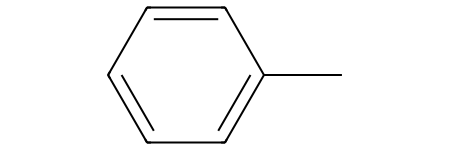

Molecule with hydrogen:


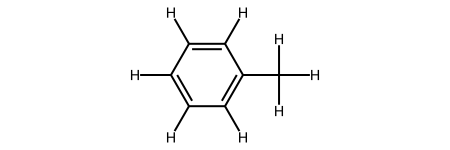

In [26]:
from IPython.display import Image, display # For Jupyter notebooks
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
from rdkit.Chem import Draw

smi = "Cc1ccccc1" # Toluene         # define the SMILES, here: toluene
mol = Chem.MolFromSmiles(smi)       # get the RDKit mol obj from SMILES
mol_with_h = Chem.AddHs(mol)        # hydrogens are treated implicitly, so we wanna see them in the graphic, we need to add them

print('Molecule without hydrogen:')
display(mol)

print('Molecule with hydrogen:')
display(mol_with_h)

Now we use our Toluene mol-object from RDKit that we generated using the SMILES and generate a binary, circular fingerprint from that:

In [27]:
radius = 2                                              # ECFP4 (radius = 2)
nBits = 2048                                            # fingerprint length

# Generate binary circular ECFP fingerprint (ECFP4)
fpgen = AllChem.GetMorganGenerator(radius=2, fpSize=nBits)
fp = fpgen.GetFingerprint(mol)

# Convert to NumPy array for ML
arr = np.zeros((nBits,), dtype=int)
DataStructs.ConvertToNumpyArray(fp, arr)

np.set_printoptions(threshold=np.inf)                     # to print the full array 

print(arr)


[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 

##### Data cleaning

** Before we apply this fingerprint generation to our whole dataset, we first need to make sure that the dataset is cleaned, which means:

* no mulitple entries
* each structure has a value assigned and vice-versa

###### Checking for multiple entries
We already learned that SMILES is not a unique representation of a molecule: One molecule can be encoded by different SMILES, such as ethanol: `CCO` or `0CC` or `C(C)0`. To check for duplets, we cannot just compare the SMILES. However, there is one solution to that problem: **Canonicalization**.

**Canonical SMILES** are a unique SMILES string assigned to a molecule by RDKit (or other cheminformatics tools), so that:

* Each molecule → exactly one canonical SMILES
* Equivalent molecules (isomers aside) → same canonical SMILES
* Ensures reproducibility and consistent hashing/fingerprints

1. RDKit convert the SMILES into a molecular graph: Atoms become nodes, bonds become edges, hydrogens are treated implicitly
2. Unique atom rankings: RDKit assigns a unique integer to each atom (based on graph topology, element type, connectivity, and optionally stereochemistry). This is called atom invariants.
3. Determine canonical traversal order: RDKit uses the atom rankings to decide a unique traversal order of the molecular graph. This traversal is deterministic — same molecule → same order.
4. Write SMILES in traversal order. RDKit outputs a SMILES string following that traversal order. Ring closures and branches are numbered deterministically.
5. Optional stereochemistry encoding: If `isomericSmiles=True` in `Chem.MolToSmiles()`, stereochemistry `(@, /, \)` is included.

Let's canonicalize our SMILES in the dataset!

In [28]:
def canonicalize(smiles):
    mol = Chem.MolFromSmiles(smiles)           # convert SMILES to RDKit mol object         
    if mol is not None:
        return Chem.MolToSmiles(mol, canonical=True, isomericSmiles=True)               # convert mol object back to canonical SMILES, take care of isomers
    else:
        return None  # invalid SMILES

df['canonical_smiles'] = df['SMILES'].apply(canonicalize)   # apply the function "canonicalize" to the whole SMILES-column and put them into the new column "canocical_smiles"

[18:31:02] Explicit valence for atom # 1 Si, 4, is greater than permitted
[18:31:02] WARNING: not removing hydrogen atom with neighbor that has non-tetrahedral stereochemistry


First, let's check for missing values. Is there any structure without value or canonical smiles?

In [29]:
print(df.isnull().sum())

Unnamed: 0          0
SMILES              0
val                 0
canonical_smiles    1
dtype: int64


We can see that:
* there is an experimental value assigned to each structure
* but there is 1 structure where the canonical SMILES is empty. The canonicalization failed. This can happen if the SMILES in the original dataset already contain errors. Let's inspect the molecule and delete this datapoint.

In [30]:
errors = df[df['canonical_smiles'].isnull()]   # filter the rows with invalid canoncical SMILES

print(errors)

      Unnamed: 0       SMILES     val canonical_smiles
7194        7194  [C-]#[SiH+]  2001.0             None


We now have two options:

* try to fix canonicalization
* delete the datapoint

Our goal is to implement a model that determines **the acute toxicity of solvents**. Solvent molecules usually have a very different structure. Therefore: Let's simply delete this datapoint.

In [31]:
df = df.dropna(subset=['canonical_smiles'])               # drop rows with invalid canonical SMILES

print('Check again: Number of missing entries:')
print(df.isnull().sum())

Check again: Number of missing entries:
Unnamed: 0          0
SMILES              0
val                 0
canonical_smiles    0
dtype: int64


Looks good now! Now we need to check whether there are multiple datapoints of the same chemical. If so we could merge multiple entries into one by taking the average.

In [32]:
df_unique = df.drop_duplicates(subset='canonical_smiles')   # drop multiple entries

print('Number of entries in the original dataset:')
print(df.shape[0])

print('Number of entries in the dataset with erased entries:')
print(df_unique.shape[0])


Number of entries in the original dataset:
7300
Number of entries in the dataset with erased entries:
7300


Same number as before! That means, our dataset did not contain duplets, nice!

##### Data analysis

After the initial analysis, let's inspect our data a bit deeper. Since the model learns from data, the model can only describe well what is has seen. What's the limits in terms of structural and value ranges? Let's have a look at the LD₅₀ values and make a histogram plot of how many extremely toxic and less toxic substances we have. 

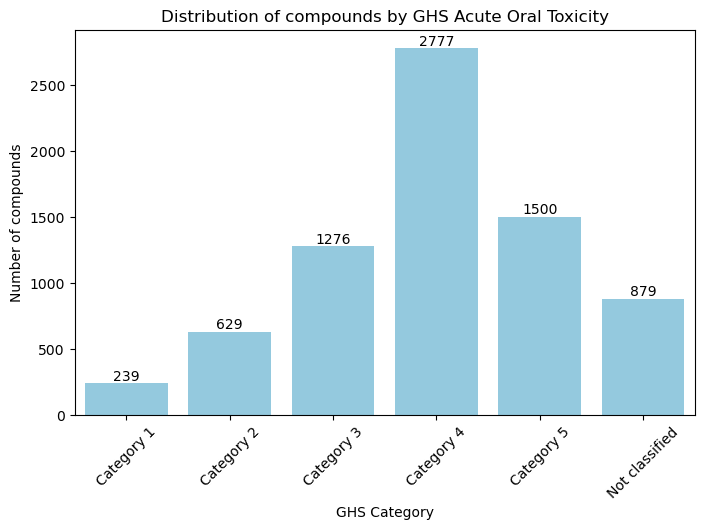

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

def ghs_category(val):                                                  # define the categories according to GHS
    if val <= 5:
        return "Category 1"
    elif val <= 50:
        return "Category 2"
    elif val <= 300:
        return "Category 3"
    elif val <= 2000:
        return "Category 4"
    elif val <= 5000:
        return "Category 5"
    else:
        return "Not classified"


df['GHS_category'] = df['val'].apply(ghs_category)                      # Add a cloumn with the GHS category

category_counts = df['GHS_category'].value_counts().sort_index()        # Count the entries per category

# Now let's plot!


plt.figure(figsize=(8,5))                                                                       # define the figure size
sns.countplot(data=df, x='GHS_category', order=[                                                # define plot...
    "Category 1","Category 2","Category 3","Category 4","Category 5","Not classified"],         # ... the order of the categories ...
    color="skyblue",                                                                            # ... the color of the bars
)
plt.xlabel("GHS Category")                                                                      # define labels and title
plt.ylabel("Number of compounds")
plt.title("Distribution of compounds by GHS Acute Oral Toxicity")
plt.xticks(rotation=45)                                                                         # rotate x-ticks for better readability

# Show counts on top of bars
for p in plt.gca().patches:                                                                     # annotate the bars with the counts    
    plt.gca().annotate(int(p.get_height()), (p.get_x() + p.get_width()/2., p.get_height()),
                       ha='center', va='bottom')

plt.show()                                                                                      # show the plot

That was easy! We see that most chemicals are Category 4 and only few are Category 1. We need to take this into account when training the model! More explanations on that later when we implement the model.
<br>
<br>
Now we need to also analyze the **structural data**. Here is how we can go from SMILES to vizualizing our chemical space.

1. Convert canconical SMILES into fingerprints
2. Dimensionality reduction
3. Plotting the reduced structural information vs toxicity values

Can we already relate some structural features to toxicity? 

Let's generate the fingerprints:

In [34]:
# put the fingerprint generation into a function
def smiles_to_fp(smiles, nBits=nBits, radius=radius):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        # Handle invalid SMILES
        arr = np.zeros((nBits,), dtype=int)
        return arr
    # Generate the fingerprint
    fp = fpgen.GetFingerprint(mol)
    arr = np.zeros((nBits,), dtype=int)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

# apply to the "canoical_smiles" column
radius = 2                                              # ECFP4 (radius = 2)
nBits = 2048                                            # fingerprint length
df['fingerprint'] = df['canonical_smiles'].apply(smiles_to_fp)

# check the result
print(df)

      Unnamed: 0                         SMILES     val  \
0              0                      Br/C=C\Br    62.0   
1              1      BrC(Br)(Br)c1ccc2ccccc2n1  6769.0   
2              2                      BrC(Br)Br   933.0   
3              3                 BrC(Br)C(Br)Br  1200.0   
4              4                    BrC/C=C/CBr    62.0   
...          ...                            ...     ...   
7296        7296               c1coc(OCC2CO2)c1  1100.0   
7297        7297   c1nc(NC2CC2)c2ncn(C3CC3)c2n1   130.0   
7298        7298  c1nc(NC2CC2)c2ncn(CC3CC3)c2n1   160.0   
7299        7299                     c1nc[nH]n1  1648.0   
7300        7300            c1nnc(NCNc2nncs2)s1   260.0   

                   canonical_smiles    GHS_category  \
0                         Br/C=C\Br      Category 3   
1         BrC(Br)(Br)c1ccc2ccccc2n1  Not classified   
2                         BrC(Br)Br      Category 4   
3                    BrC(Br)C(Br)Br      Category 4   
4               

[18:31:03] WARNING: not removing hydrogen atom with neighbor that has non-tetrahedral stereochemistry


Our structural information is now stored in the fingerprints, each having 2048 bits. However, we cannot plot 2048 dimensions. Let's reduce this dimension to 2, so we can vizualize the structures them in a 2D scatter plot.

Techniques for dimensionaly reduction are:
* Principal Component Analysis (PCA): Find the directions (principal components) that capture the most variance in the data. Only captures linear relationships, may miss complex chemical patterns.
* t-SNE (t-distributed Stochastic Neighbor Embedding): Preserves local structure — molecules that are similar in high dimensions stay close in 2D. (non-linear method)
* UMAP (Uniform Manifold Approximation and Projection): Non-linear, preserves both local and global structure better than t-SNE in many cases. (non-linear method)

**t-SNE**

As we will use t-SNE, we will look a bit deeper in how it works. t-SNE stands for t-distributed Stochastic Neighbor Embedding and is a dimensionality-reduction method mainly used for visualization.

* maps high-dimensional data to 2D or 3D while preserving local neighborhood structure.
* points that are close together in the original space tend to stay close in the embedding.
* distances between far-apart clusters are not meaningful and should not be over-interpreted.
* it is not a predictive model and cannot easily embed new points without rerunning.

t-SNE is best used for exploration and visualization, not for quantitative analysis.

How is it different from PCA and UMAP?

PCA: Linear method, preserves maximum variance in the data
UMAP: Nonlinear method, preserves local neighborhoods and some global structure, much faster than t-SNE, handles large datasets well


Now, we will learn how to reduce the high-dimensional fingerprint into 2D so we can plot the structural space. 

In [35]:
from sklearn.manifold import TSNE



X = np.stack(df['fingerprint'].values)  # shape: (n_samples, 2048)
tsne = TSNE(
    n_components=2, 
    perplexity=30,       # typical: 5-50, adjust for your dataset size
    learning_rate=200,   # default is usually fine
    metric='jaccard',    # good for binary fingerprints
    random_state=42, 
    n_iter=1000          # increase for better convergence if needed
)

X_2d = tsne.fit_transform(X)  # shape: (n_samples, 2) Note: This might take a while depending on your device

df['tSNE1'] = X_2d[:,0]
df['tSNE2'] = X_2d[:,1]





/home/koenigmattern/anaconda3/lib/python3.13/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/home/koenigmattern/anaconda3/lib/python3.13/site-packages/sklearn/metrics/pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


Great! We saved both t-SNE-derived dimensions for each chemical in the dataframe. Now we want to plot the results: Plot the structures in 2D space and give each dot - corresponding to a chemical - a color representing the LD50.

In [36]:
from bokeh.plotting import figure, ColumnDataSource, show, output_file
from bokeh.models import HoverTool, Div, CustomJS, ColorBar
from bokeh.transform import linear_cmap
from bokeh.palettes import Viridis256
from bokeh.io import output_file
import base64
from io import BytesIO

# --- convert SMILES to base64 image, so we dont need to save them locally (7300 images would require quite some storage) ---
def smiles_to_image_base64(smiles, size=(150,150)):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return ""  # empty string
    img = Draw.MolToImage(mol, size=(150,150))
    buf = BytesIO()
    img.save(buf, format="PNG")
    return base64.b64encode(buf.getvalue()).decode("utf-8")
   
    

# --- prepare DataFrame ---
df['mol_image'] = df['canonical_smiles'].apply(smiles_to_image_base64)  # apply the function to generate base64 images
df['capped_vals'] = np.clip(df['val'], 0, 5000)                   # cap the values at 5000 for better color mapping

source = ColumnDataSource(data=dict(            # prepare the data source for Bokeh
    x=df['tSNE1'],
    y=df['tSNE2'],
    capped_vals=df['capped_vals'],
    smiles=df['canonical_smiles'],
    img=df['mol_image']
))

# define the tooltips for hover function
tooltips = """                                                        
<div style="display:flex; gap:10px;">
  <div><img src="data:image/png;base64,@img" width="150"></div>
  <div style="max-width:300px;">
    <div><b>SMILES:</b> @smiles</div>
    <div><b>LD 50 (mg/kg):</b> @capped_vals</div>
  </div>
</div>
"""

# --- create the figure ---
p = figure(width=800, height=600, title="Chemical space: t-SNE 2D with Acute Oral Toxicity",
           tools="pan,wheel_zoom,reset,save", active_scroll="wheel_zoom")

p.add_tools(HoverTool(tooltips=tooltips))

# --- scatter plot with color mapping ---
color_mapper = linear_cmap(field_name='capped_vals', palette=Viridis256, low=0, high=5000)
p.scatter(x='x', y='y', source=source, size=6, fill_alpha=0.5, line_color=None, color=color_mapper)


# --- color bar ---
color_bar = ColorBar(color_mapper=color_mapper['transform'], width=8, location=(0,0), label_standoff=12, title="LD50 (mg/kg)")
p.add_layout(color_bar, 'right')

# --- save ---
output_file(conv_name("img/chemical_space_tsne_hover.html"))
show(p)  # opens in browser and writes HTML

[18:32:11] WARNING: not removing hydrogen atom with neighbor that has non-tetrahedral stereochemistry


Now let's use another way to viszualize the structural space. Let's classify each molecule (e.g. hydrocarbon, lipds, .....) and the count each occurence. Note: Since one molecule can be assigned to one or more categories, there will be more counts than molecules in the dataset.

Gtk-Message: 18:32:12.636: Not loading module "atk-bridge": The functionality is provided by GTK natively. Please try to not load it.
Gtk-Message: 18:32:12.704: Failed to load module "canberra-gtk-module"
Gtk-Message: 18:32:12.706: Failed to load module "canberra-gtk-module"


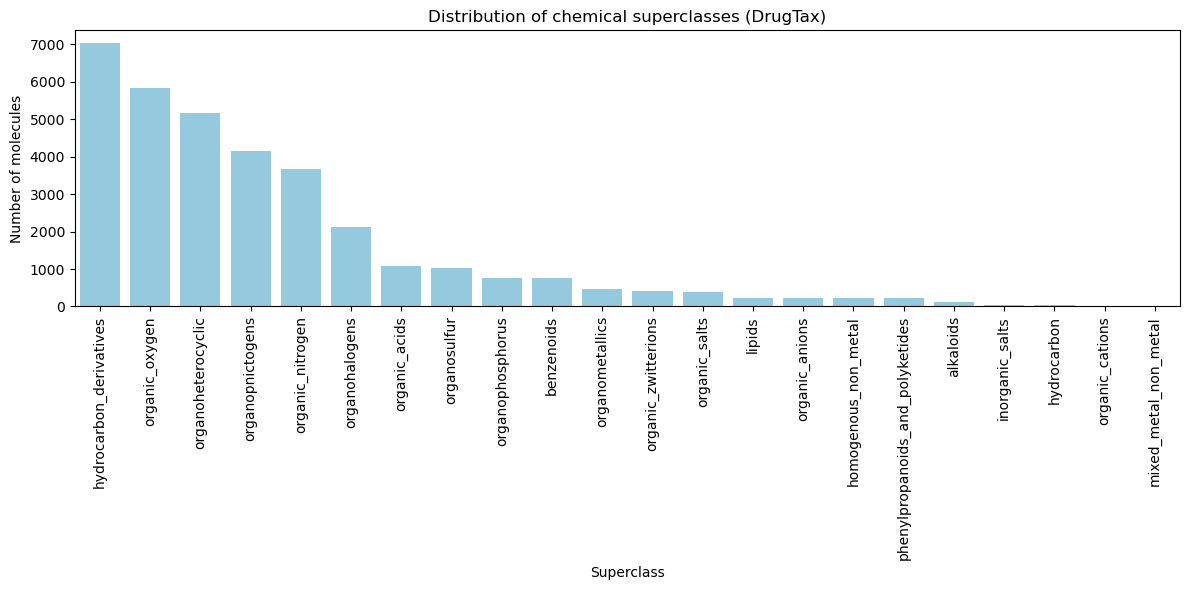

In [37]:
import drugtax
import collections


# convert SMILES to DrugTax and get superclasses 
def get_superclasses(smiles):
    try:
        mol = drugtax.DrugTax(smiles)
        return mol.superclasses  # returns a list of superclasses
    except:
        return []  # in case of invalid SMILES

df['superclasses'] = df['canonical_smiles'].apply(get_superclasses)

# flatten the list of superclasses for histogram
# Each row may have multiple superclasses --> expand into a long list
all_classes = [cls for sublist in df['superclasses'] for cls in sublist]


# plot the distribution of superclasses
counts = collections.Counter(all_classes)
sorted_classes = dict(sorted(counts.items(), key=lambda x: x[1], reverse=True))

plt.figure(figsize=(12,6))
sns.barplot(x=list(sorted_classes.keys()), y=list(sorted_classes.values()), color='skyblue')
plt.xticks(rotation=90)
plt.xlabel("Superclass")
plt.ylabel("Number of molecules")
plt.title("Distribution of chemical superclasses (DrugTax)")
plt.tight_layout()
plt.show()

We see that while for some classes, there are plenty datapoints, there are only few for e.g. metal-containing chemicals and ionic species. Our model will have limited predicitve power for those chemicals with few data available!

**Recap**

* We have made our molecules "machine-readble" by converting them to fingerprints
* We have collected, cleaned and analyzed our dataset

**Next step** Model implementation


### Model implementation


#### Selecting the right algorithm

<center> <img src="../img/data_driven_modelling/supervised_unsupervised.png" alt="../img/data_driven_modelling/supervised_unsupervised.png"width="700"/> </center>

<center> <img src="../img/ml_map.svg" alt="../img/ml_map.svg" width="700"/> </center>


The algorithm to be chosen also largely depends on the size and the quality of the dataset. As a rule of thumb, choose these algorithms as a first try:

* 50 - 1000 datapoints: Linear models, Random Forest, Support Vector Machines, Gradient Boosting, Gaussian Process Models
* 1000 - 10000 datapoints: Random Forest, Gradient Boosting, Graph Neural Networks, Deep Neural Networks
* 10000 - 100000 datapoints: Graph Neural Networks, Deep Neural Networks, Transfer Learning
* $>$ 100000: Large Language Models, Transformers
<br>
<br>

**Considerations for our model**
* Our dataset has input and output given: Supervised learning
* Goal: predict continuous values of LD₅₀ &rarr; Regression task
* Dataset size: Our dataset is too small for large language models but would be suitable for Random Forests, Gradient Boosting or Graph Neural Networks.

<br>
<br>

Graph Neural Networks are very powerful (as you will see later) but a bit more complex to implement. Due to time reasons, we choose the **Random Forest Algorithm** for our problem.

##### Random Forest Algorithm

Random Forest (RF) is an ensemble learning algorithm that combines many simple decision trees to make a robust prediction. Instead of relying on a single decision tree, a random forest builds many different trees and combines their predictions. 
<br>
What is a decision tree? 
A decision tree is a model that makes predictions by asking a sequence of simple yes/no questions about the input features. 
* Start with all data at the root
* Split the data based on one feature (e.g. “Is this fingerprint bit = 1?”)
* Repeat splitting until the data is sufficiently pure
* Make a prediction at the leaf nodes

In the RF algorithm, multiple trees are combined, since trainign only on one tree is prone to overfitting (we'll see later what this exactly means)
<br>

The RF algorithm follows these steps:
1. Bootstrap sampling: Each tree is trained on a random subset of the data (sampling with replacement).
2. Random feature selection: At each split in a tree, only a random subset of features is considered.
3. Grow many trees: Each tree learns slightly different decision rules.
4. Aggregate predictions: Regression: average over all trees, Classification: majority vote

More detailed information: `Breiman, “Random Forests”, Machine Learning, 45(1), 5-32, 2001.`, `P. Geurts, D. Ernst., and L. Wehenkel, “Extremely randomized trees”, Machine Learning, 63(1), 3-42, 2006.`

But before we can train our RF model, we need to split our dataset into training and testing. The training set is used for building the actual model, in general contains about 70 - 80 % of the data. The test set is used to evaluate the model performance and contains about 30 - 20 % of the data. Let's split the data and train the model!

Train metrics: RMSE=1568.45, MAE=716.29, R2=0.870
Test metrics:  RMSE=3748.50, MAE=1871.87, R2=0.183


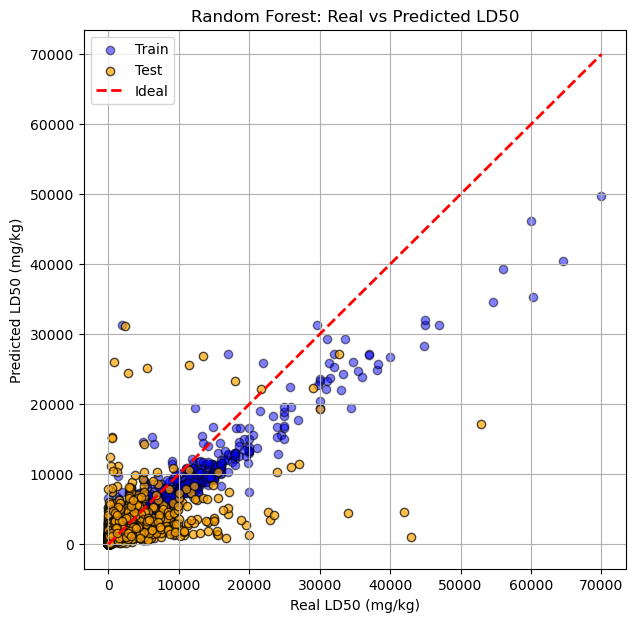

In [38]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

# Convert list of arrays to 2D NumPy array for ML
X = np.stack(df['fingerprint'].values)
y = df['val'].values

# --- Split the dataset ---

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- Train Random Forest ---
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# --- Predictions ---
y_train_pred = rf.predict(X_train)
y_test_pred  = rf.predict(X_test)

# --- Compute metrics ---
def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

metrics_train = regression_metrics(y_train, y_train_pred)
metrics_test  = regression_metrics(y_test, y_test_pred)

print("Train metrics: RMSE={:.2f}, MAE={:.2f}, R2={:.3f}".format(*metrics_train))
print("Test metrics:  RMSE={:.2f}, MAE={:.2f}, R2={:.3f}".format(*metrics_test))

# --- Scatter plot: Real vs Predicted ---
plt.figure(figsize=(7,7))

# Training data
plt.scatter(y_train, y_train_pred, color='blue', alpha=0.5, edgecolors='k', label='Train')

# Test data
plt.scatter(y_test, y_test_pred, color='orange', alpha=0.7, edgecolors='k', label='Test')

# Perfect prediction line
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Ideal')

plt.xlabel("Real LD50 (mg/kg)")
plt.ylabel("Predicted LD50 (mg/kg)")
plt.title("Random Forest: Real vs Predicted LD50")
plt.legend()
plt.grid(True)
plt.show()

##### Regression Evaluation Metrics

Let $y_i $ be the true values, $\hat{y}_i$ the predicted values, and $n$ the number of samples.

---

**Mean Absolute Error (MAE)**

Definition:

$$
\mathrm{MAE} = \frac{1}{n}\sum_{i=1}^{n} \left| y_i - \hat{y}_i \right|
$$

Explanation:
- Measures the average absolute difference between predictions and true values.
- Has the same units as the target variable.
- Penalizes all errors linearly and is relatively robust to outliers.


**Root Mean Squared Error (RMSE)**

Definition:

$$
\mathrm{RMSE} = \sqrt{ \frac{1}{n}\sum_{i=1}^{n} \left( y_i - \hat{y}_i \right)^2 }
$$

Explanation:
- Squares errors before averaging, then takes the square root.
- Penalizes large errors more strongly than MAE.
- Has the same units as the target variable.


**Coefficient of Determination $R^2$**

Definition:

$$
R^2 = 1 - \frac{\sum_{i=1}^{n} \left( y_i - \hat{y}_i \right)^2}
{\sum_{i=1}^{n} \left( y_i - \bar{y} \right)^2}
$$

where $\bar{y}$ is the mean of the true values.

Explanation:
- Measures the fraction of variance in the data explained by the model.
- Compares the model to a baseline that predicts the mean.
- Dimensionless quantity.

Interpretation:
- $R^2 = 1$: perfect prediction  
- $R^2 = 0$: no improvement over the mean  
- $R^2 < 0$: worse than predicting the mean

We see that the model does not perform well in its current form: The MAE is high (spans multiple toxicity categories) and the $R²$ is low.

In its current form, the model needs to handle values ranging from close to 0 up to 50000.

On the raw scale:
* values are typically heteroscedastic (larger variance at higher values)
* small LD₅₀ differences at low values (e.g. 5 → 10 mg kg⁻¹) are toxicologically huge
* large absolute differences at high values (10 000 → 20 000 mg kg⁻¹) are often less meaningful

** This is hard to handle for ML algorithms!**

In our case, it makes sense to transform our values to a logarithmic scale because most regression models implicitly assume:
* reduces heteroscedasticity
* errors of similar scale across the target range
* roughly symmetric distributions
* makes the distribution more symmetric

This leads to:
* more stable training
* better generalization
* more meaningful uncertainty estimates

**A log transform compresses the scale so that relative differences matter, not absolute ones.**

{'MAE Train': 0.2685312254937708, 'RMSE Train': np.float64(0.37741052792307134), 'R2 Train': 0.8191540522386493, 'MAE Val': 0.4578030263617658, 'RMSE Val': np.float64(0.6142167167035415), 'R2 Val': 0.5148369780287341}


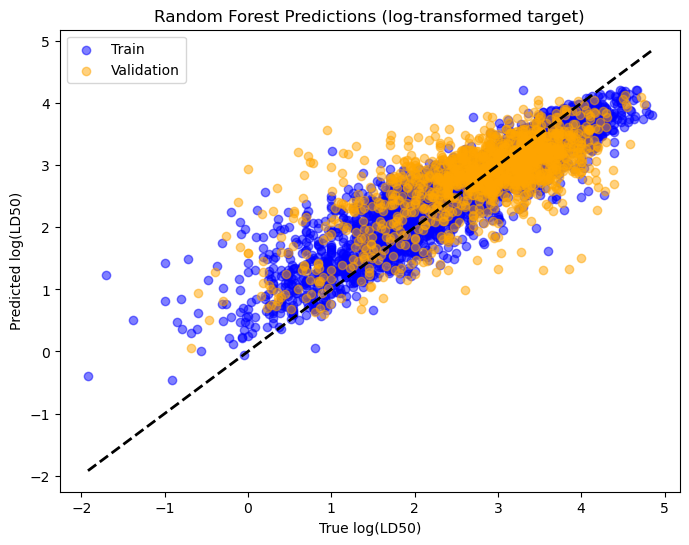

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

# --- Features and target ---
X = np.stack(df['fingerprint'].values)  # fingerprints as NumPy array
y = df['val'].to_numpy()                 # LD50 values

stratify_labels = df['GHS_category'].values  # stratify by GHS categories

# --- Log-transform target ---
y_log = np.log10(y) 
df['log10_vals'] = y_log

# --- Train-test split ---
X_train, X_val, y_train_log, y_val_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42, stratify=stratify_labels
    
)


# --- Fit Random Forest ---
rf = RandomForestRegressor(
    n_estimators=50,           # More trees → stable predictions
    max_depth=None,             # Let trees expand fully
    min_samples_split=10,        # Avoid splits with very few samples
    min_samples_leaf=2,         # Leaf must have at least 2 samples
    bootstrap=True,             # Use bootstrap sampling (standard RF)
    n_jobs=-1,                  # Use all cores for speed
    random_state=42,            # Reproducibility
)
rf.fit(X_train, y_train_log)

# --- Predict (in log space) ---
y_train_pred = rf.predict(X_train)
y_val_pred   = rf.predict(X_val)

# --- Metrics in log space ---
metrics = {
    "MAE Train": mean_absolute_error(y_train_log, y_train_pred),
    "RMSE Train": np.sqrt(mean_squared_error(y_train_log, y_train_pred)),
    "R2 Train": r2_score(y_train_log, y_train_pred),
    "MAE Val": mean_absolute_error(y_val_log, y_val_pred),
    "RMSE Val": np.sqrt(mean_squared_error(y_val_log, y_val_pred)),
    "R2 Val": r2_score(y_val_log, y_val_pred)
}

print(metrics)

# --- Scatter plot: True vs Predicted (log space) ---
plt.figure(figsize=(8,6))
plt.scatter(y_train_log, y_train_pred, color='blue', alpha=0.5, label='Train')
plt.scatter(y_val_log, y_val_pred, color='orange', alpha=0.5, label='Validation')
plt.plot([y_log.min(), y_log.max()], [y_log.min(), y_log.max()], 'k--', lw=2)
plt.xlabel("True log(LD50)")
plt.ylabel("Predicted log(LD50)")
plt.title("Random Forest Predictions (log-transformed target)")
plt.legend()
plt.show()

The scatter plot now shows:

* lower accuracy at low LD50, higher accuracy at high LD50 --> difference to raw scale

Looking at the metrics:

* MAE is about 0.5 in log₁₀(LD₅₀). This corresponds to a multiplicative error of about a factor of 3 ($10^{0.5} = 3.16$). The model predicts LD₅₀ values within a factor of ~3 on average.
* $R^2$ is still relatively low. This could be caused by:
    * missing descriptors (we could add more descriptors using RDKit easily)
    * intrinsic noise in LD₅₀ data (we cannot change that)
    * limited sample size (we cannot change that either)
    * that the structure–toxicity relationship is weak (if so, we can't change that)


Take-homes: On the raw scale, the model is dominated by large LD₅₀ values → low LD₅₀ compounds look badly predicted. On the log scale, the model optimizes relative (multiplicative) error, so low LD₅₀ values are no longer overwhelmed and high LD₅₀ values can tolerate larger absolute errors. On the log scale, accuracy becomes more uniform in relative terms, not necessarily higher everywhere.

Note: Take into account that the error metrics are given in log-unit now as well, so they cannot be directly compared.

Next, we could try adding more features in addition to the fingerprints.

[18:34:10] WARNING: not removing hydrogen atom with neighbor that has non-tetrahedral stereochemistry


{'MSE Train': 0.11449525204667592, 'MAE Train': 0.23758825937647127, 'RMSE Train': np.float64(0.33837147049755234), 'R2 Train': 0.8546321932663443, 'MSE Val': 0.36585624426194224, 'MAE Val': 0.4429712361352789, 'RMSE Val': np.float64(0.604860516368809), 'R2 Val': 0.529505121905089}


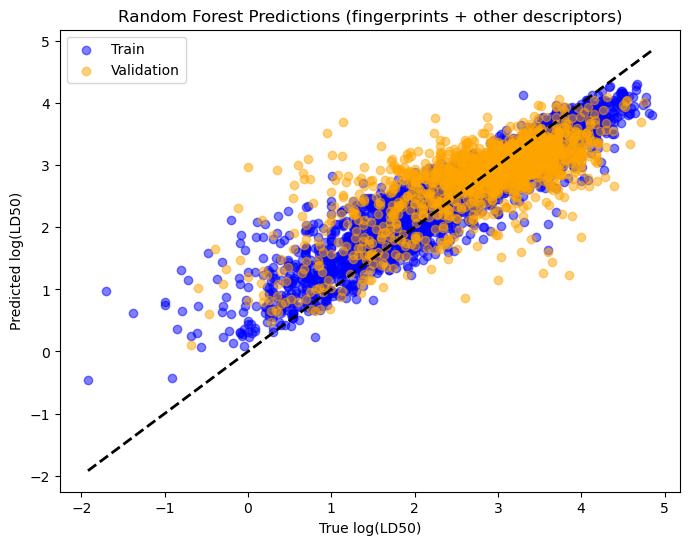

In [40]:
from rdkit import Chem
from rdkit.Chem import Descriptors
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- Compute descriptors ---
desc_names = ['MolWt','HeavyAtomMolWt','ExactMolWt','NumValenceElectrons','NumRadicalElectrons',
              'MaxAbsEStateIndex','MinAbsEStateIndex','MaxEStateIndex','MinEStateIndex',
              'BalabanJ','BertzCT','MolLogP','MolMR','TPSA','FractionCSP3',
              'NumRotatableBonds','RingCount','NumHAcceptors','NumHDonors']

def compute_physchem_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return [np.nan]*len(desc_names)
    return [getattr(Descriptors, name)(mol) for name in desc_names]

# Filter missing fingerprints
df = df[df['fingerprint'].notnull()].reset_index(drop=True)

# Compute descriptors
desc_values = df['canonical_smiles'].apply(compute_physchem_descriptors)
desc_df = pd.DataFrame(desc_values.tolist(), columns=desc_names)
df = pd.concat([df, desc_df], axis=1)

# --- Features ---
X_fp = np.stack(df['fingerprint'].values)        # fingerprints as NumPy array
X_desc = df[desc_names].to_numpy()              # RDKit descriptors

# --- Scale descriptors ---
scaler = StandardScaler()
X_desc_scaled = scaler.fit_transform(X_desc)

# Combine features
X = np.hstack([X_fp, X_desc_scaled])

# --- Target (log10 LD50) ---
y_log = np.log10(df['val'].to_numpy())

# --- Stratified split by GHS category ---
stratify_labels = df['GHS_category'].values
X_train, X_val, y_train_log, y_val_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42, stratify=stratify_labels
)

# --- Random Forest ---
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train_log)

# --- Predictions ---
y_train_pred = rf.predict(X_train)
y_val_pred   = rf.predict(X_val)

# --- Metrics ---
metrics = {
    "MSE Train": mean_squared_error(y_train_log, y_train_pred),
    "MAE Train": mean_absolute_error(y_train_log, y_train_pred),
    "RMSE Train": np.sqrt(mean_squared_error(y_train_log, y_train_pred)),
    "R2 Train": r2_score(y_train_log, y_train_pred),
    "MSE Val": mean_squared_error(y_val_log, y_val_pred),
    "MAE Val": mean_absolute_error(y_val_log, y_val_pred),
    "RMSE Val": np.sqrt(mean_squared_error(y_val_log, y_val_pred)),
    "R2 Val": r2_score(y_val_log, y_val_pred)
}
print(metrics)

# --- Scatter plot ---
plt.figure(figsize=(8,6))
plt.scatter(y_train_log, y_train_pred, color='blue', alpha=0.5, label='Train')
plt.scatter(y_val_log, y_val_pred, color='orange', alpha=0.5, label='Validation')
plt.plot([y_log.min(), y_log.max()], [y_log.min(), y_log.max()], 'k--', lw=2)
plt.xlabel("True log(LD50)")
plt.ylabel("Predicted log(LD50)")
plt.title("Random Forest Predictions (fingerprints + other descriptors)")
plt.legend()
plt.show()

Unfortunately, adding these descriptors does not improve the accuracy. 

**Do we really need absolute toxicity values or is it sufficient to discriminate between toxic and non-toxic molecules?**

Let's move away from a regression model to a binary classification model. This model is trained to recognize toxic and non-toxic molecules based on their fingerprint. For the classification, we define GHS categories 1 - 4 as toxic and 5 and above as non-toxic.


As an overview, here are commonly used solvents that are rated to be not acutely toxic: 


| Solvent           | Approx. Oral LD₅₀ (mg/kg, rat) | Likely GHS Category | Notes                                      |
|------------------|---------------------------------|-------------------|--------------------------------------------|
| Acetone           | 3687–5250                       | 5                 | Very widely used, low acute toxicity       |
| Xylene (mixed)    | 4300                             | 5                 | Common in histology and organic synthesis  |
| 1‑Butanol         | 4360                             | 5                 | Alcohol, moderate miscibility in water    |
| Methyl acetate    | 3700                             | 5                 | Common ester solvent                        |
| Heptane           | 4196                             | 5                 | Nonpolar hydrocarbon solvent               |
| Ethanol           | 7060                             | Not classified    | Widely used, very low acute toxicity       |
| DMSO              | 14500                            | Not classified    | Very low acute toxicity, often used as carrier solvent |
| Methanol          | 5628                             | 5                 | Toxic in high doses, also chronic toxicity concern |
| Acetonitrile      | 3250                             | 5                 | Volatile, moderately toxic                 |
| Toluene           | 5580                             | Not classified    | Aromatic solvent, volatile                 |


Note: Some solvents may have chronic toxicity, mutagenicity, or reproductive hazards, so acute oral toxicity is not the only concern.

In [41]:
# now lets develop the classification model
# 
# from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# --- Features ---
X = np.stack(df['fingerprint'].values)  # fingerprints

# --- Target: binary ---
def binary_toxicity(val):
    cat = ghs_category(val)
    return 0 if (cat == "Not classified" or cat == 'Category 5') else 1  # 1 = toxic, 0 = non-toxic

y = df['val'].apply(binary_toxicity).to_numpy()

# --- Stratify by toxicity to keep balance ---
stratify_labels = y

# --- Train-test split ---
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=stratify_labels
)

# --- Random Forest Classifier ---
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42,
    class_weight='balanced'  # helps if classes are imbalanced
)
rf.fit(X_train, y_train)

# --- Predict ---
y_train_pred = rf.predict(X_train)
y_val_pred   = rf.predict(X_val)

# --- Metrics ---
print("Train classification report:")
print(classification_report(y_train, y_train_pred, digits=3))

print("Validation classification report:")
print(classification_report(y_val, y_val_pred, digits=3))

print("Validation confusion matrix:")
print(confusion_matrix(y_val, y_val_pred))

Train classification report:
              precision    recall  f1-score   support

           0      0.850     0.921     0.884      1903
           1      0.960     0.922     0.941      3937

    accuracy                          0.921      5840
   macro avg      0.905     0.921     0.912      5840
weighted avg      0.924     0.921     0.922      5840

Validation classification report:
              precision    recall  f1-score   support

           0      0.608     0.603     0.605       476
           1      0.809     0.812     0.810       984

    accuracy                          0.744      1460
   macro avg      0.708     0.707     0.708      1460
weighted avg      0.743     0.744     0.744      1460

Validation confusion matrix:
[[287 189]
 [185 799]]


##### Evaluation metrics for binary classification

**Confusion Matrix** (Binary Classification)**

|                | Predicted Positive | Predicted Negative |
|---------------|-------------------|-------------------|
| **Actual Positive** | True Positive (TP) | False Negative (FN) |
| **Actual Negative** | False Positive (FP) | True Negative (TN) |

All classification metrics are derived from these four quantities.



**Accuracy**:

Definition:

$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$

Explanation
- Fraction of correctly classified samples.
- Easy to interpret, but often misleading.

Limitation

- Not suitable for imbalanced datasets.



**Precision (Positive Predictive Value)**

Definition:

$$
\text{Precision} = \frac{TP}{TP + FP}
$$

Explanation:
- Of all samples predicted as positive, how many are truly positive?
- Penalizes false positives.

Use when:
- False positives are costly.

**Recall (Sensitivity, True Positive Rate)**

Definition:
$$
\text{Recall} = \frac{TP}{TP + FN}
$$

Explanation:
- Of all actual positive samples, how many were correctly identified?
- Penalizes false negatives.

Use when:
- Missing positive samples is costly.


**F1-score**

Definition:
$$
\text{F1} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}
{\text{Precision} + \text{Recall}}
$$

Explanation

- Harmonic mean of precision and recall.
- Balances false positives and false negatives.
- Useful for imbalanced datasets.

With this knowledge, let's evaluate our classification results!


**Training Performance**

The model shows strong performance on the training data, with an overall accuracy of **0.921**.

- **Class 0 (non-toxic)**:
  - Precision = 0.85
  - Recall = 0.921
  - F1-score = 0.884  
  The model correctly identifies most non-toxic compounds, with a small number of false positives.

- **Class 1 (toxic)**:
  - Precision = 0.96
  - Recall = 0.922
  - F1-score = 0.941  
  The toxic class is predicted with very high precision and recall, indicating that toxic compounds are both rarely missed and rarely misclassified.

Overall, the training results indicate a well-performing model with slightly better performance for the toxic class than for the non-toxic class.



**Validation Performance**

On the validation set, performance drops noticeably, with an overall accuracy of **0.744**, indicating reduced generalization.

- **Class 0 (non-toxic)**:
  - Precision = 0.608
  - Recall = 0.603
  - F1-score = 0.605  
  The model struggles to correctly identify non-toxic compounds, with a substantial number of false positives and false negatives.

- **Class 1 (toxic)**:
  - Precision = 0.809
  - Recall = 0.812
  - F1-score = 0.810  
  Performance for the toxic class remains relatively strong, showing that the model is more reliable at detecting toxic compounds than non-toxic ones.


### Confusion Matrix Analysis

Confusion matrix (validation set):
$$
\begin{pmatrix}
287 & 189 \\
185 & 799
\end{pmatrix}
$$

- **True non-toxic (TN)**: 287  
- **False toxic (FP)**: 189  
- **False non-toxic (FN)**: 185  
- **True toxic (TP)**: 799  

The confusion matrix confirms that:
- Toxic compounds are identified reasonably well.
- Some non-toxic compounds are incorrectly classified as toxic.
- The model exhibits a **bias toward predicting the toxic class**, which explains the higher recall and precision for toxic compounds compared to non-toxic ones.


**From a safety perspective, prioritizing recall for the toxic class may be acceptable, but at the cost of some false alarms.**